In [1]:
import pandas as pd

df = pd.read_csv("Nat_Gas.csv")

print(df.head())
print(df.dtypes)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from statsmodels.tsa.holtwinters import ExponentialSmoothing

      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9
Dates      object
Prices    float64
dtype: object


In [2]:
# Convert dates
df["Dates"] = pd.to_datetime(df["Dates"])

# Sort data
df = df.sort_values("Dates")

C:\Users\GOMTI\AppData\Local\Temp\ipykernel_25076\3227688201.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


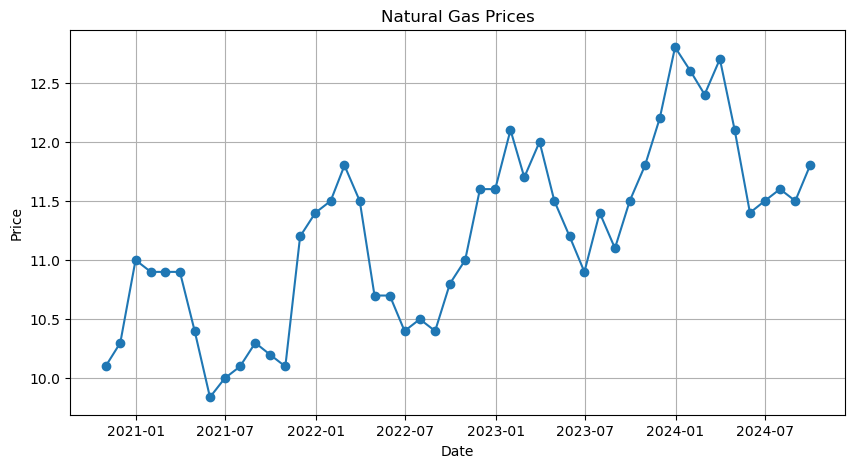

In [3]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], df["Prices"], marker="o")
plt.title("Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [4]:

# Set date as index
df.set_index("Dates", inplace=True)


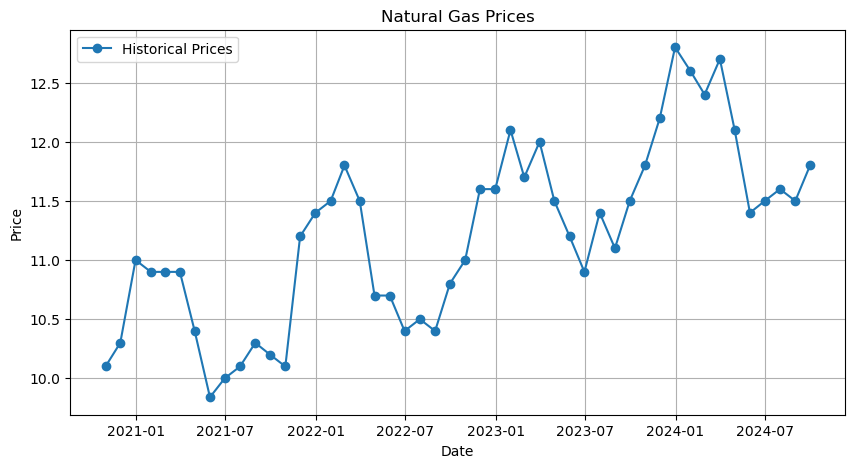

In [5]:
# ----------------------------
# Plot Historical Prices
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Prices"], marker='o', label="Historical Prices")
plt.title("Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()


In [6]:
# ----------------------------
# Holt-Winters Model
# ----------------------------
model = ExponentialSmoothing(
    df["Prices"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()


c:\Users\GOMTI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [7]:
# ----------------------------
# Forecast Next 12 Months
# ----------------------------
forecast = fit.forecast(12)

forecast_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq="M"
)

forecast_df = pd.DataFrame({
    "Dates": forecast_dates,
    "Forecast": forecast.values
})

print(forecast_df)

        Dates   Forecast
0  2024-10-31  12.103782
1  2024-11-30  12.678810
2  2024-12-31  13.053791
3  2025-01-31  13.128799
4  2025-02-28  13.053792
5  2025-03-31  13.128793
6  2025-04-30  12.528778
7  2025-05-31  12.138793
8  2025-06-30  12.053781
9  2025-07-31  12.253789
10 2025-08-31  12.178798
11 2025-09-30  12.428808


C:\Users\GOMTI\AppData\Local\Temp\ipykernel_25076\1354019844.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(


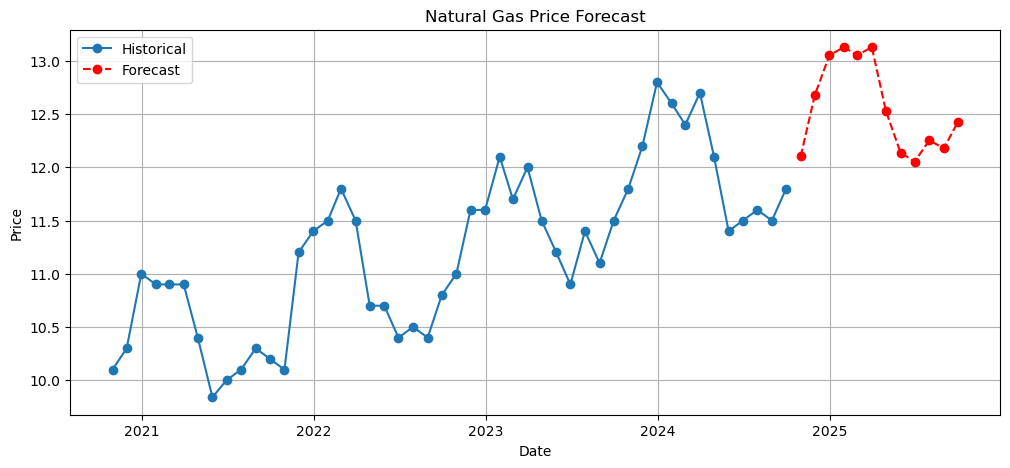

In [8]:
# ----------------------------
# Plot Forecast
# ----------------------------
plt.figure(figsize=(12,5))

plt.plot(df.index,
         df["Prices"],
         marker='o',
         label="Historical")

plt.plot(forecast_dates,
         forecast,
         marker='o',
         linestyle='--',
         color='red',
         label="Forecast")

plt.title("Natural Gas Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()

plt.show()


In [9]:
def estimate_price(date):

    date = pd.to_datetime(date)

    # Historical period
    if date <= df.index[-1]:

        if date in df.index:
            return df.loc[date, "Prices"]

        return float(
            df["Prices"]
            .reindex(df.index.union([date]))
            .sort_index()
            .interpolate(method="time")
            .loc[date]
        )

    # Forecast period (next 12 months)
    elif date <= forecast_dates[-1]:

        return float(
            forecast
            .reindex(forecast.index.union([date]))
            .sort_index()
            .interpolate(method="time")
            .loc[date]
        )

    else:
        return "Date beyond forecast range."

In [10]:
print(estimate_price("2023-05-15"))

print(estimate_price("2025-06-20"))

11.354838709677418
12.082118188352212
